# Generative Adversarial Network (GAN) – MNIST

**Name:** Praveenkumar  
**Roll No:** 24BAD090  
**Experiment:** Implementation of GAN for Synthetic Image Generation  
**Dataset:** MNIST Handwritten Digits  
**Platform:** Google Colab


## AIM
To implement a Generative Adversarial Network (GAN) for generating synthetic images by training a Generator and Discriminator on the MNIST image dataset and evaluating the quality of generated images.


## PART A – Dataset Preparation and Image Preprocessing
Load MNIST, explore the dataset, display sample images, normalize pixels to [-1, 1], reshape the images, and create a TensorFlow data pipeline.


In [3]:
# ============================================================
# Name    : Praveenkumar
# Roll No : 24BAD090
# Part A: Dataset Preparation and Image Preprocessing
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist

print("TensorFlow Version:", tf.__version__)
print("Name: Praveenkumar")
print("Roll No: 24BAD090")


TensorFlow Version: 2.21.0
Name: Praveenkumar
Roll No: 24BAD090


In [4]:
# Load MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of training images:", len(X_train))
print("Image dimensions:", X_train.shape[1], "x", X_train.shape[2])


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of training images: 60000
Image dimensions: 28 x 28


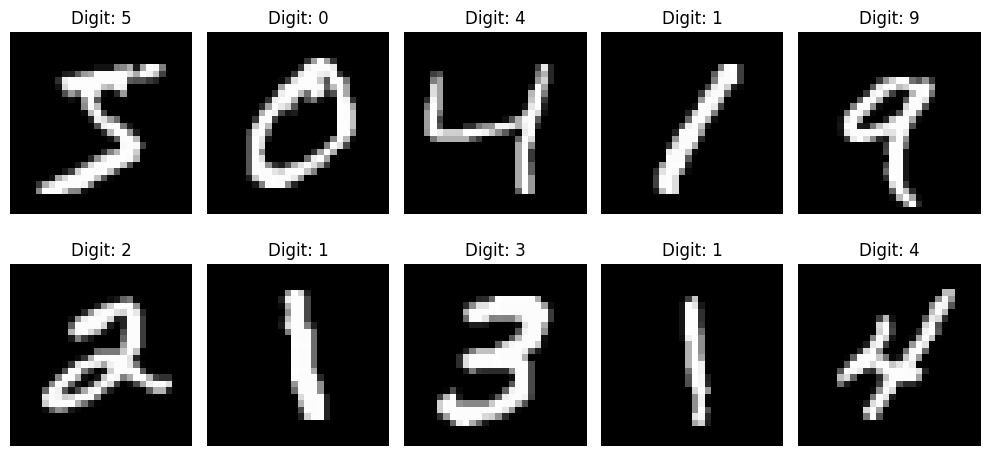

In [5]:
# Display sample images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
# Normalize pixel values from [0, 255] to [-1, 1]

X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())


Minimum pixel value: -1.0
Maximum pixel value: 1.0


In [7]:
# Reshape images to (28, 28, 1)

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)

print("New training shape:", X_train.shape)


New training shape: (60000, 28, 28, 1)


In [8]:
# Create TensorFlow data pipeline

BATCH_SIZE = 128

dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(60000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset pipeline created successfully.")
print("Batch size:", BATCH_SIZE)


Dataset pipeline created successfully.
Batch size: 128


## PART B – Implementing the Generator
The Generator accepts a 100-dimensional random noise vector and transforms it into a 28×28 grayscale image using Dense and transposed convolution layers.


In [9]:
# ============================================================
# Part B: Generator
# Name    : Praveenkumar
# Roll No : 24BAD090
# ============================================================

from tensorflow.keras import layers
from tensorflow.keras import Sequential

NOISE_DIM = 100

generator = Sequential([
    layers.Input(shape=(NOISE_DIM,)),

    layers.Dense(7 * 7 * 128, use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7, 7, 128)),

    layers.Conv2DTranspose(
        64, kernel_size=5, strides=2,
        padding="same", use_bias=False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        32, kernel_size=5, strides=2,
        padding="same", use_bias=False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2D(
        1, kernel_size=5,
        padding="same", activation="tanh"
    )
], name="Generator")

generator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,473 (3.47 MB)

 Trainable params: 896,737 (3.42 MB)

 Non-trainable params: 12,736 (49.75 KB)

In [10]:
# Generate an image before training

random_noise = tf.random.normal([1, NOISE_DIM])
generated_image = generator(random_noise, training=False)

print("Generated image shape:", generated_image.shape)


Generated image shape: (1, 28, 28, 1)


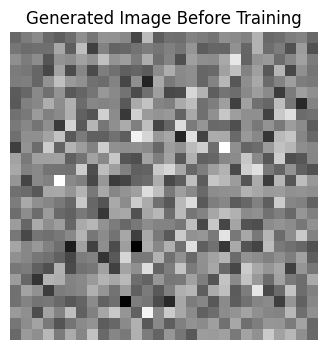

In [11]:
# Display generated image before GAN training

plt.figure(figsize=(4, 4))
plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()


## PART C – Implementing the Discriminator and GAN Model
The Discriminator classifies input images as real or fake. Binary cross-entropy is used as the loss function and Adam is used as the optimizer.


In [12]:
# ============================================================
# Part C: Discriminator
# Name    : Praveenkumar
# Roll No : 24BAD090
# ============================================================

discriminator = Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        64, kernel_size=5, strides=2, padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(
        128, kernel_size=5, strides=2, padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
], name="Discriminator")

discriminator.summary()


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile Discriminator

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator.compile(
    optimizer=discriminator_optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Discriminator compiled successfully.")


Discriminator compiled successfully.


In [14]:
# Test Discriminator with real and generated images

real_image = X_train[0:1]
fake_image = generator(
    tf.random.normal([1, NOISE_DIM]),
    training=False
)

real_prediction = discriminator(real_image)
fake_prediction = discriminator(fake_image)

print("Discriminator prediction for real image:",
      real_prediction.numpy())
print("Discriminator prediction for fake image:",
      fake_prediction.numpy())


Discriminator prediction for real image: [[0.49006647]]
Discriminator prediction for fake image: [[0.5005552]]


In [15]:
# Build combined GAN model

# Freeze discriminator for generator training through the combined GAN
discriminator.trainable = False

gan_input = layers.Input(shape=(NOISE_DIM,))
gan_generated_image = generator(gan_input)
gan_output = discriminator(gan_generated_image)

gan = tf.keras.Model(
    gan_input,
    gan_output,
    name="GAN"
)

gan.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss="binary_crossentropy"
)

gan.summary()


Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 28, 28, 1)      │       909,473 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,122,338 (4.28 MB)

 Trainable params: 896,737 (3.42 MB)

 Non-trainable params: 225,601 (881.25 KB)

## PART D – GAN Training and Synthetic Image Generation
The GAN is trained adversarially. The Discriminator learns from real and generated images, while the Generator learns to produce images that can fool the Discriminator.


In [16]:
# ============================================================
# Part D: GAN Training
# Name    : Praveenkumar
# Roll No : 24BAD090
# ============================================================

import tensorflow as tf

EPOCHS = 5
BATCH_SIZE = 128

train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(60000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training Configuration")
print("----------------------")
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Noise Dimension:", NOISE_DIM)

Training Configuration
----------------------
Epochs: 5
Batch Size: 128
Noise Dimension: 100


In [17]:
# GAN loss and optimizers

cross_entropy = tf.keras.losses.BinaryCrossentropy()

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    # -----------------------------
    # Train Discriminator
    # -----------------------------
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        real_loss = cross_entropy(
            tf.ones_like(real_output), real_output
        )
        fake_loss = cross_entropy(
            tf.zeros_like(fake_output), fake_output
        )

        d_loss = real_loss + fake_loss

    d_gradients = d_tape.gradient(
        d_loss, discriminator.trainable_variables
    )

    discriminator_optimizer.apply_gradients(
        zip(d_gradients, discriminator.trainable_variables)
    )

    # -----------------------------
    # Train Generator
    # -----------------------------
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as g_tape:
        generated_images = generator(noise, training=True)
        fake_output = discriminator(generated_images, training=True)

        g_loss = cross_entropy(
            tf.ones_like(fake_output), fake_output
        )

    g_gradients = g_tape.gradient(
        g_loss, generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(g_gradients, generator.trainable_variables)
    )

    return g_loss, d_loss


In [18]:
# Function to generate and display images

def generate_and_display_images(epoch):
    noise = tf.random.normal([16, NOISE_DIM])
    predictions = generator(noise, training=False)

    plt.figure(figsize=(8, 8))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle("Generated Images - Epoch " + str(epoch))
    plt.tight_layout()
    plt.show()


Epoch 1/5 | Generator Loss: 0.7829 | Discriminator Loss: 1.3087


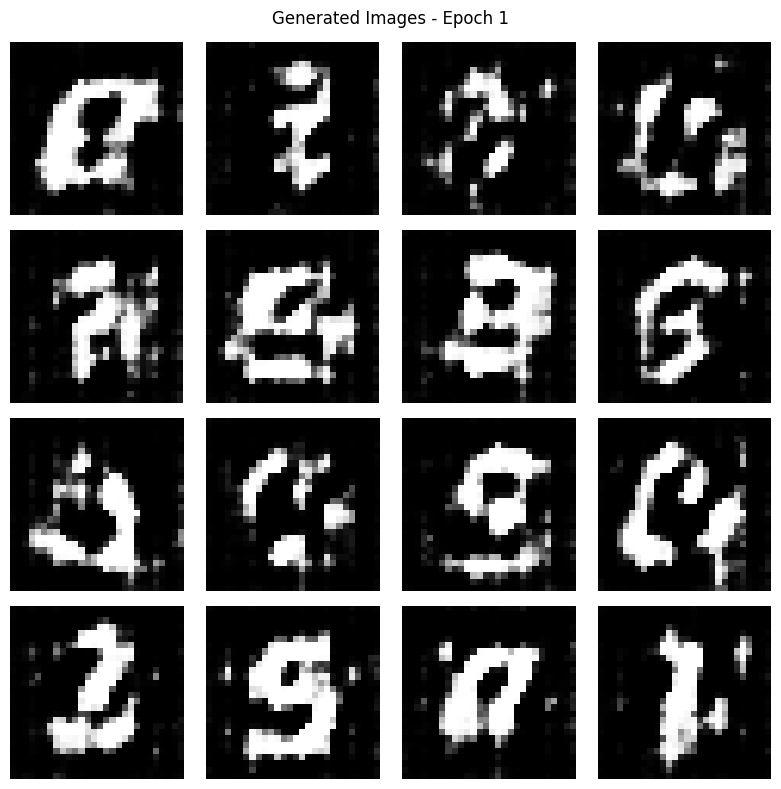

Epoch 2/5 | Generator Loss: 0.8286 | Discriminator Loss: 1.2935


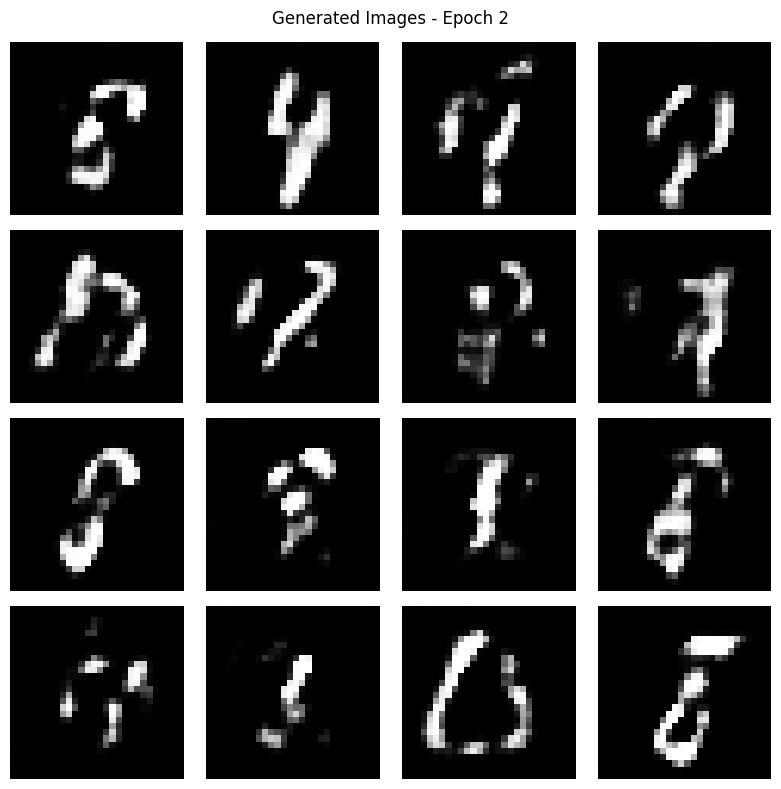

Epoch 3/5 | Generator Loss: 0.9091 | Discriminator Loss: 1.2256


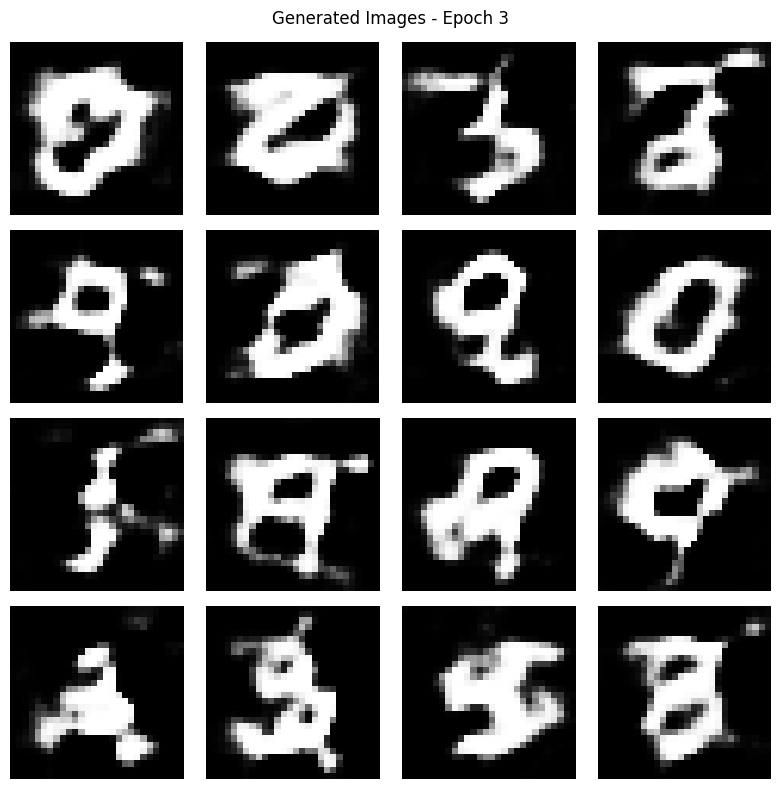

Epoch 4/5 | Generator Loss: 0.8411 | Discriminator Loss: 1.2785


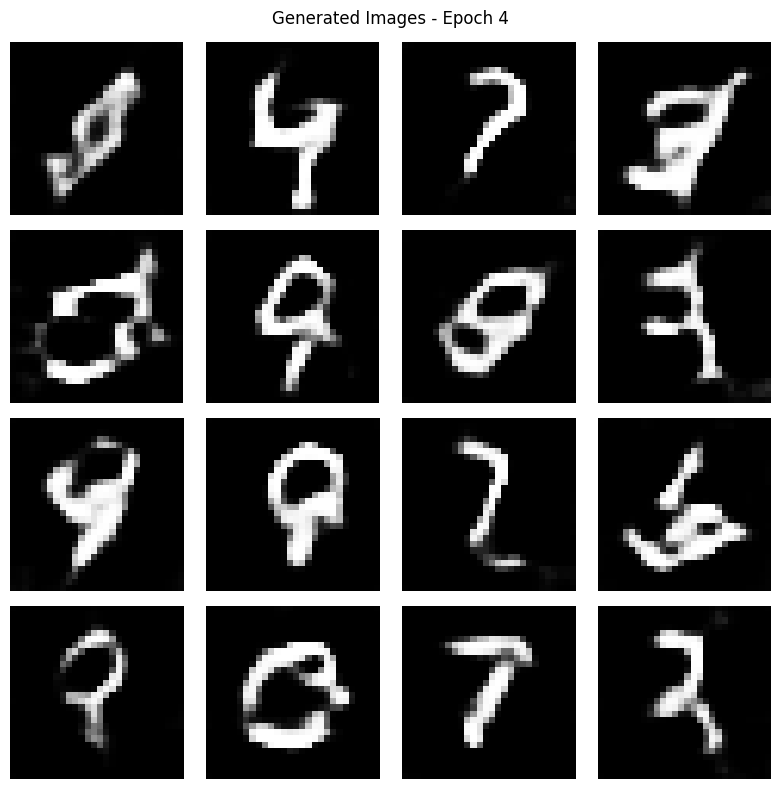

Epoch 5/5 | Generator Loss: 0.8163 | Discriminator Loss: 1.3115


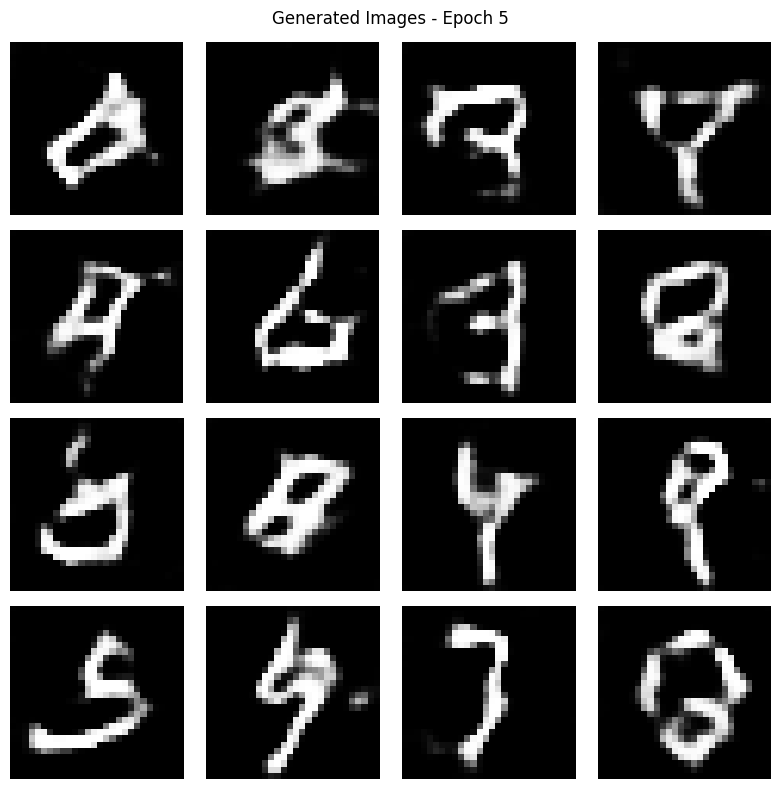

In [19]:
# Train GAN with fewer epochs
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Ensure generator and discriminator exist in the current session state
try:
    generator
except NameError:
    NOISE_DIM = 100
    generator = Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 128)),
        layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2D(1, kernel_size=5, padding="same", activation="tanh")
    ], name="Generator")

try:
    discriminator
except NameError:
    discriminator = Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, kernel_size=5, strides=2, padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128, kernel_size=5, strides=2, padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid")
    ], name="Discriminator")

try:
    cross_entropy
except NameError:
    cross_entropy = tf.keras.losses.BinaryCrossentropy()

# Ensure discriminator weights are fully trainable
discriminator.trainable = True

# Recreate optimizers to avoid state mismatch or variable reconstruction errors
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

# Redefine the train_step function to be compiled with fresh tracking
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    # -----------------------------
    # Train Discriminator
    # -----------------------------
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)
        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = real_loss + fake_loss

    d_gradients = d_tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

    # -----------------------------
    # Train Generator
    # -----------------------------
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as g_tape:
        generated_images = generator(noise, training=True)
        fake_output = discriminator(generated_images, training=True)
        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

    g_gradients = g_tape.gradient(g_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))

    return g_loss, d_loss

generator_losses = []
discriminator_losses = []

for epoch in range(1, EPOCHS + 1):
    g_loss_total = 0.0
    d_loss_total = 0.0
    batches = 0

    for real_images in train_dataset:
        g_loss, d_loss = train_step(real_images)
        g_loss_total += float(g_loss)
        d_loss_total += float(d_loss)
        batches += 1

    avg_g_loss = g_loss_total / batches
    avg_d_loss = d_loss_total / batches

    generator_losses.append(avg_g_loss)
    discriminator_losses.append(avg_d_loss)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Generator Loss: {avg_g_loss:.4f} | "
        f"Discriminator Loss: {avg_d_loss:.4f}"
    )

    # Visualize output more frequently since epochs are reduced
    if epoch % 1 == 0:
        generate_and_display_images(epoch)

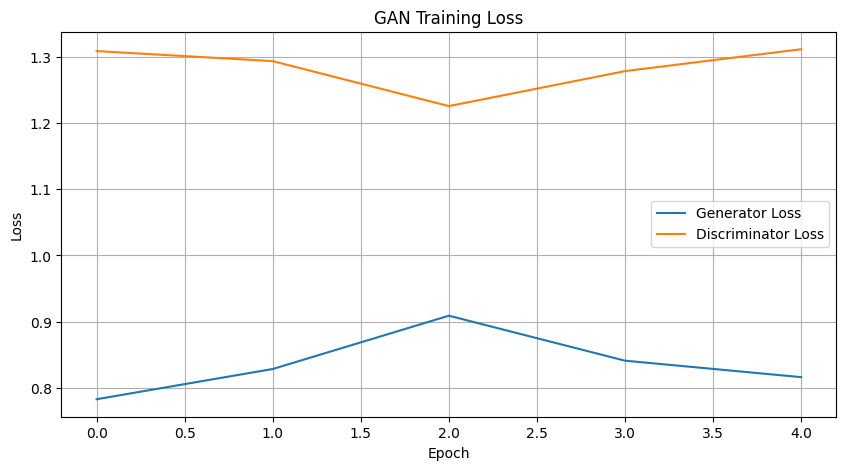

In [20]:
# Plot Generator and Discriminator losses

plt.figure(figsize=(10, 5))

plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()


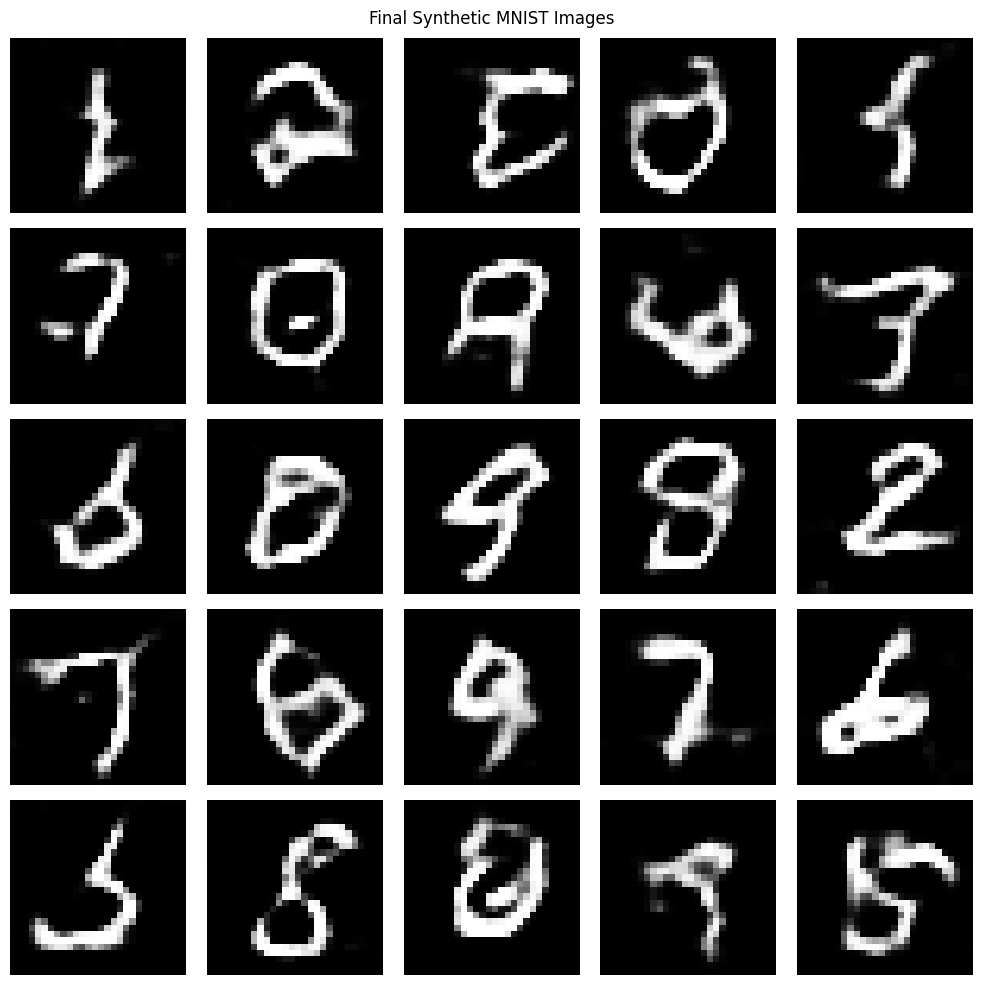

In [21]:
# Generate final synthetic images

noise = tf.random.normal([25, NOISE_DIM])
final_images = generator(noise, training=False)

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(final_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.suptitle("Final Synthetic MNIST Images")
plt.tight_layout()
plt.show()


In [22]:
# Save final generated images

import os

os.makedirs("generated_images", exist_ok=True)

for i in range(25):
    image = final_images[i, :, :, 0].numpy()
    image = ((image + 1) * 127.5).clip(0, 255).astype(np.uint8)

    plt.imsave(
        f"generated_images/generated_{i+1}.png",
        image,
        cmap="gray"
    )

print("25 synthetic images saved successfully.")


25 synthetic images saved successfully.


In [23]:
# Save trained models

generator.save("trained_generator.keras")
discriminator.save("trained_discriminator.keras")

print("Generator saved successfully.")
print("Discriminator saved successfully.")


Generator saved successfully.
Discriminator saved successfully.


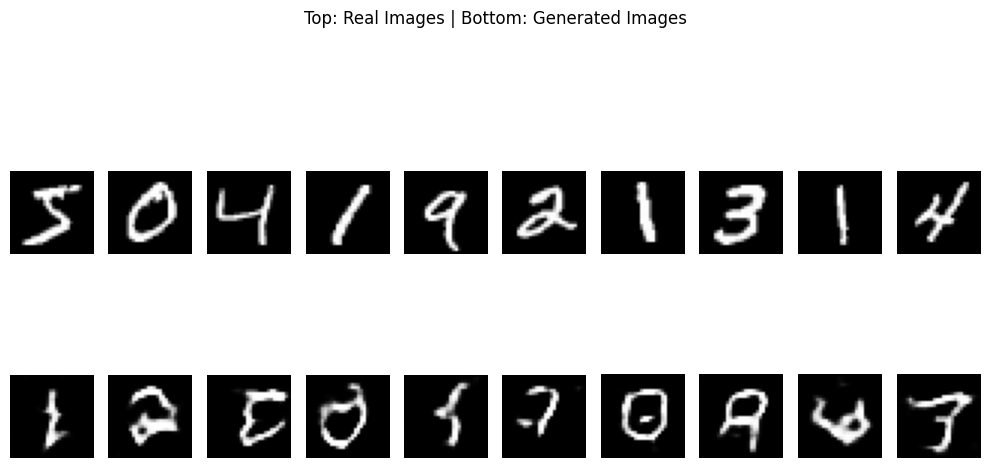

In [24]:
# Compare real and generated images

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_train[i, :, :, 0], cmap="gray")
    plt.axis("off")

for i in range(10):
    plt.subplot(2, 10, 10 + i + 1)
    plt.imshow(final_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Real Images | Bottom: Generated Images")
plt.tight_layout()
plt.show()


## EXPECTED OUTCOME

The GAN successfully learns the distribution of MNIST handwritten digits. The Generator learns to create synthetic digit-like images from random noise, while the Discriminator learns to distinguish real MNIST images from generated images. The quality of generated images improves during adversarial training.

## RESULT

Thus, a Generative Adversarial Network was successfully implemented using TensorFlow/Keras and MNIST, and synthetic handwritten digit images were generated and visualized.
